# Etapa 1 Predição do Preço Hedônico de Referência

**Objetivo:** A primeira etapa consiste em prever o preço esperado de transferência do jogador com base em seus atributos esportivos, contratuais e demográficos. O resíduo entre o preço pago e o preço estimado (`Y_i,c = ln(P_i) - ln(P̂_i)`) é o **prêmio de reinvestimento** que será usado na Etapa 2 (Double ML).

**Dados:** `output/transfers_modeling_ready.csv`: 2.144 transferências pagas, temporadas 2023–2025.

## Pipeline

| Seção | Descrição |
|-------|-----------|
| 0. Setup | Imports, carregamento, sanity check |
| 1. Preparação de features | Seleção de X e y, encoding, train/test split |
| 2. Modelos | XGBoost · LightGBM · Random Forest · SVR |
| 3. Avaliação comparativa | RMSE, MAE, R² — tabela + gráficos |
| 4. Interpretabilidade | SHAP values do melhor modelo |
| 5. Cálculo do resíduo hedônico | Exportar `premio_reinvestimento` para Etapa 2 |

---
**Membros**
> Carlos Ferreira dos Santos Junior - 2019054412

> César de Paulo Moraes

> Leticia Ribeiro Miranda - 2021095686

> Lucas Ferreira Pedras - 2021030835

> Lucca ALvarenga de Magalhães Pinto - 2021036736

## 0. Setup

In [ ]:
#pip install xgboost lightgbm catboost scikit-learn shap matplotlib seaborn

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 11.6 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 8.8 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.6 MB/s  0:00:09m0:00:0100:01
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 12.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 13.5 MB/s  0:00:21m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [catboost]/11 [catboost]cl-cu12]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Avaliação e seleção
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Interpretabilidade
import shap

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

print('Imports OK')

Imports OK


In [3]:
df = pd.read_csv('../output/transfers_modeling_ready.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (2144, 40)


,player,buyer,seller,season_id,competition_code,country_name,premium_ratio,premium_ratio_w,hedonic_residual,pi_hedonic_pct,...,log_league_mv,in_degree,out_degree,pagerank,in_strength,out_strength,net_flow,season_id.1,season_2024,season_2025
0,Luis Suárez,Sporting CP,UD Almería,2025,liga-portugal,Portugal,1.868750,1.868750,1.364201,291.259472,...,21.343842,8,0,0.006499,90171000.0,0.0,-90171000.0,2025,0,1
1,Fotis Ioannidis,Sporting CP,Panathinaikos,2025,liga-portugal,Portugal,0.466667,0.466667,0.576457,77.972109,...,21.343842,8,0,0.006499,90171000.0,0.0,-90171000.0,2025,0,1
2,Luís Guilherme,Sporting CP,West Ham,2025,liga-portugal,Portugal,0.400000,0.400000,0.000320,0.032029,...,21.343842,8,0,0.006499,90171000.0,0.0,-90171000.0,2025,0,1


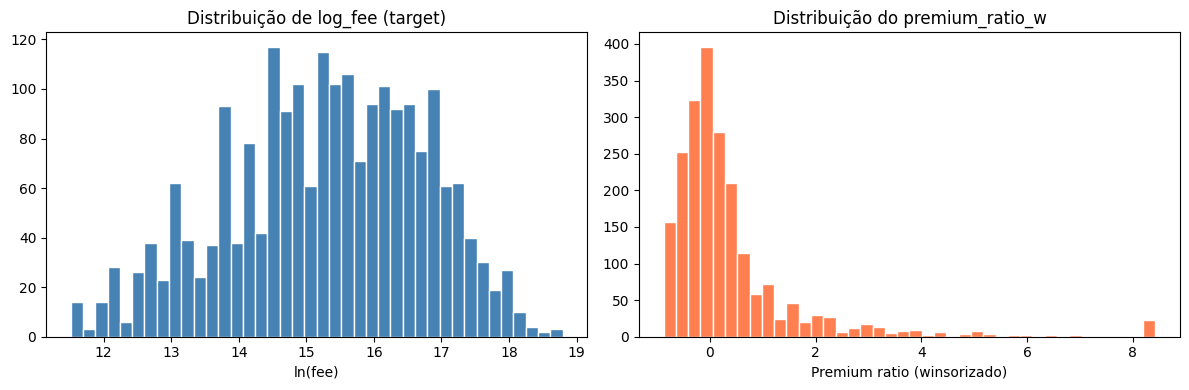

        log_fee  premium_ratio_w  hedonic_residual
count  2144.000         2144.000          2144.000
mean     15.281            0.398             0.000
std       1.454            1.385             0.733
min      11.513           -0.878            -4.745
25%      14.346           -0.333            -0.387
50%      15.425            0.000             0.045
75%      16.381            0.500             0.421
max      18.792            8.428             2.853


In [4]:
# Sanity check: distribuição da variável dependente
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['log_fee'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de log_fee (target)')
axes[0].set_xlabel('ln(fee)')

axes[1].hist(df['premium_ratio_w'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribuição do premium_ratio_w')
axes[1].set_xlabel('Premium ratio (winsorizado)')

plt.tight_layout()
plt.show()

print(df[['log_fee', 'premium_ratio_w', 'hedonic_residual']].describe().round(3))

## 1. Preparação de Features

### 1.1 Definição do target e das covariáveis

O target é `log_fee` (ln do valor da transação):  
> *"A variável dependente desta fase é o logaritmo do valor da transação: ln(Pᵢ)"*

O conjunto de covariáveis (`X_atleta`) deve incluir:
- Atributos biográficos: `age`, `age²`
- Performance: features de performance disponíveis no dataset
- Contrato e clube de origem: features do feature_engineering
- Controles de mercado: `log_league_mv`, efeitos fixos de temporada

> **TODO:** revisar se há features adicionais de performance disponíveis (minutos jogados, gols/90, etc.) após merge com outras fontes.

> **TODO:** ANÁLISE QUAIS features serão as covariáveis, pega todas as colunas do csv? se não for, quais vamos pegar?

In [ ]:
# TARGET
TARGET = 'log_fee'

# FEATURES 
# Atributos do jogador
cols_player = [
    'age',
    # 'age_sq',          # TODO: criar age² abaixo
    'is_attacker',
    'is_midfielder',
    'is_defender',
    'log_mv',           # market value como proxy de habilidade intrínseca
]

# Atributos do clube e mercado
cols_market = [
    'log_league_mv',    # nível competitivo da liga de destino
    'squad_size',
    'average_age',
    'national_team_players',
]

# Efeitos fixos de temporada (dummies já presentes no CSV)
cols_fe = [c for c in df.columns if c.startswith('season_')]

FEATURES = cols_player + cols_market + cols_fe

print(f'Target: {TARGET}')
print(f'Total de features: {len(FEATURES)}')
print(FEATURES)

In [ ]:
# Criar age² para capturar não-linearidade do ciclo biológico
df['age_sq'] = df['age'] ** 2
FEATURES.insert(1, 'age_sq')   # inserir logo após 'age'

# TODO: adicionar outras features de performance quando disponíveis
# Ex: df['goals_per90'], df['minutes_played'], df['contract_years_remaining']

### 1.2 Train / Test Split

Usamos divisão temporal: treino em temporadas 2023–2024, teste em 2025.  
Isso evita *data leakage* e simula um cenário realista de previsão fora da amostra.

In [ ]:
# Divisão temporal: 2023-2024 → treino | 2025 → teste
train_mask = df['season_id'].isin([2023, 2024])
test_mask  = df['season_id'] == 2025

X_train = df.loc[train_mask, FEATURES]
y_train = df.loc[train_mask, TARGET]

X_test  = df.loc[test_mask, FEATURES]
y_test  = df.loc[test_mask, TARGET]

print(f'Treino: {X_train.shape[0]} obs | Teste: {X_test.shape[0]} obs')

# Verificar nulos
assert X_train.isnull().sum().sum() == 0, 'Nulos no treino!'
assert X_test.isnull().sum().sum()  == 0, 'Nulos no teste!'

## 2. Modelos

Cada subseção treina um modelo, realiza **cross-validation de 5 folds** no conjunto de treino e avalia no conjunto de teste.

A função auxiliar `evaluate_model` padroniza as métricas reportadas.

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """Treina, faz CV e avalia no teste. Retorna dict de métricas."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)

    # Cross-validation no treino
    cv_rmse = np.sqrt(-cross_val_score(
        model, X_tr, y_tr,
        scoring='neg_mean_squared_error', cv=kf
    ))

    # Fit final e avaliação no teste
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    metrics = {
        'Modelo'        : name,
        'CV RMSE (mean)': cv_rmse.mean().round(4),
        'CV RMSE (std)' : cv_rmse.std().round(4),
        'Test RMSE'     : np.sqrt(mean_squared_error(y_te, y_pred)).round(4),
        'Test MAE'      : mean_absolute_error(y_te, y_pred).round(4),
        'Test R²'       : r2_score(y_te, y_pred).round(4),
    }
    return metrics, model, y_pred

results = []  # acumular resultados de todos os modelos
fitted_models = {}  # guardar modelos ajustados
predictions   = {}  # guardar predições no teste

### 2.1 XGBoost

In [ ]:
# XGBoost 
# TODO: ajustar hiperparâmetros via GridSearchCV ou Optuna se necessário
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

m, fitted_models['XGBoost'], predictions['XGBoost'] = evaluate_model(
    'XGBoost', xgb_model, X_train, y_train, X_test, y_test
)
results.append(m)
print(m)

### 2.2 LightGBM

In [ ]:
# LightGBM 
lgbm_model = LGBMRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

m, fitted_models['LightGBM'], predictions['LightGBM'] = evaluate_model(
    'LightGBM', lgbm_model, X_train, y_train, X_test, y_test
)
results.append(m)
print(m)

### 2.3 Random Forest

In [ ]:
# Random Forest 
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=-1,
    oob_score=True,   # OOB error como métrica extra
)

m, fitted_models['RandomForest'], predictions['RandomForest'] = evaluate_model(
    'RandomForest', rf_model, X_train, y_train, X_test, y_test
)
results.append(m)
print(m)
print(f'OOB R²: {fitted_models["RandomForest"].oob_score_:.4f}')

### 2.4 Support Vector Regression (SVR)

> **Nota:** SVR requer escalonamento das features. Usamos um `Pipeline` com `StandardScaler`.

In [ ]:
# SVR 
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'))
])

m, fitted_models['SVR'], predictions['SVR'] = evaluate_model(
    'SVR', svr_pipeline, X_train, y_train, X_test, y_test
)
results.append(m)
print(m)

## 3. Avaliação Comparativa

In [ ]:
# Tabela comparativa
df_results = pd.DataFrame(results).set_index('Modelo')
display(df_results.style.highlight_min(
    subset=['CV RMSE (mean)', 'Test RMSE', 'Test MAE'], color='lightgreen'
).highlight_max(
    subset=['Test R²'], color='lightgreen'
))

In [ ]:
# Gráfico: Previsto vs Observado para cada modelo
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = ŷ')
    ax.set_title(name)
    ax.set_xlabel('log_fee observado')
    ax.set_ylabel('log_fee previsto')
    r2 = r2_score(y_test, y_pred)
    ax.annotate(f'R² = {r2:.3f}', xy=(0.05, 0.9), xycoords='axes fraction', fontsize=11)
    ax.legend()

plt.suptitle('Previsto vs Observado — Etapa 1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Gráfico: distribuição dos resíduos (log_fee - ŷ) por modelo
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    residuals = y_test.values - y_pred
    ax.hist(residuals, bins=40, color='coral', edgecolor='white')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(f'{name} — Distribuição dos Resíduos')
    ax.set_xlabel('Resíduo (log_fee - ŷ)')

plt.tight_layout()
plt.show()

## 4. Interpretabilidade — SHAP Values

Usamos SHAP no **melhor modelo** (menor Test RMSE) para identificar quais features mais contribuem para o preço hedônico estimado.

In [ ]:
# Identificar melhor modelo
best_name = df_results['Test RMSE'].idxmin()
best_model = fitted_models[best_name]
print(f'Melhor modelo por Test RMSE: {best_name}')

In [ ]:
# SHAP 
# Para tree-based models (XGBoost, LightGBM, RF) usar TreeExplainer
# Para SVR usar KernelExplainer (mais lento — reduzir amostra)

if best_name in ['XGBoost', 'LightGBM', 'RandomForest']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
else:
    # SVR — usar sample menor para viabilizar o cálculo
    X_sample = X_test.sample(min(200, len(X_test)), random_state=SEED)
    explainer = shap.KernelExplainer(
        best_model.predict,
        shap.sample(X_train, 100)
    )
    shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title(f'SHAP Summary — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Bar plot — importância média |SHAP|
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, plot_type='bar', show=False)
plt.title(f'Importância Média |SHAP| — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Cálculo do Resíduo Hedônico e Exportação

O prêmio de reinvestimento é o resíduo do melhor modelo aplicado a **todas** as observações (treino + teste):

$$Y_{i,c} = \ln(P_i) - \ln(\hat{P}_i)$$

Esse resíduo isola as características intrínsecas do atleta, deixando no termo de erro apenas as forças de mercado conjunturais da negociação, exatamente o que será modelado na Etapa 2 via Double ML.

In [ ]:
# Predição em todo o dataset (treino + teste)
X_all = df[FEATURES]

df['log_fee_hat'] = fitted_models[best_name].predict(X_all)

# Resíduo hedônico = Y_i,c  (será a variável dependente da Etapa 2)
df['premio_reinvestimento'] = df['log_fee'] - df['log_fee_hat']

print('Distribuição do prêmio de reinvestimento (resíduo hedônico):')
print(df['premio_reinvestimento'].describe().round(4))

In [ ]:
# Visualizar distribuição do resíduo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['premio_reinvestimento'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Sem prêmio')
axes[0].set_title('Distribuição do Prêmio de Reinvestimento')
axes[0].set_xlabel('ln(P) − ln(P̂)')
axes[0].legend()

# Prêmio médio por temporada
mean_by_season = df.groupby('season_id')['premio_reinvestimento'].mean()
axes[1].bar(mean_by_season.index.astype(str), mean_by_season.values, color='coral')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Prêmio Médio por Temporada')
axes[1].set_ylabel('Prêmio médio (log scale)')

plt.tight_layout()
plt.show()

In [ ]:
# Exportar dataset enriquecido com o resíduo hedônico para a Etapa 2
output_path = '../output/transfers_etapa2_ready.csv'

df.to_csv(output_path, index=False)

print(f'Exportado: {output_path}')
print(f'Shape: {df.shape}')
print(f'\nColunas adicionadas: log_fee_hat, premio_reinvestimento')
print(f'\nSanity check — prêmio médio: {df["premio_reinvestimento"].mean():.4f} (esperado ≈ 0 no treino)')

## Resumo dos Resultados

> **TODO (preencher após rodar):**
> - Melhor modelo: `___`
> - Test RMSE: `___`  | Test R²: `___`
> - Feature mais importante (SHAP): `___`
> - Observações com prêmio > 0 (sobrepreço): `___` %
> - Próximo passo: passar `transfers_etapa2_ready.csv` para a Etapa 2 (Double ML)